#### ML Fundamentals Day_41
***
- Scratch Implementation of Supervided ML Algorithms
   - Linear Regression
   - Logistic Regression
   - KNN Classifier
   - KNN Regressor

In [1]:
# Linear Regression

class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def fit(self, X, y): # X_train, y_train
        m, n = X.shape # (number of samples, number of features)

        # STEP1 - initialize params
        self.bias = 0
        self.weights = np.zeros(n) # [0, 0, ..., 0]

        # Gradient Descent
        for i in range(self.n_iter):
            # STEP2 - calc y_pred
            y_pred = self.bias + np.dot(X, self.weights)
    
            # STEP3 - calc gradient
            db = (1/m) * np.sum(y_pred - y)
            dw = (1/m) * np.dot(X.T, (y_pred - y))
    
            # STEP4 - convergence theorem - params update
            self.bias -= self.lr * db
            self.weights -= self.lr * dw

    def predict(self, X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred

In [2]:
import numpy as np
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
print(y_pred)

print(model.bias)
print(model.weights)

[2.06850809 4.04226297 6.01601785 7.98977273 9.96352761]
0.09475321533750963
[1.97375488]


In [3]:
# Linear reg with OLS
class LinearRegressionOLS:
    def __init__(self):
        self.bias = None
        self.weights = None

    def fit(self, X, y):
        m, n = X.shape

        X_b = np.c_[np.ones((m, 1)), X]

        # normal equation
        # theta = np.dot( np.linealg.inv(np.dot(X_b.T, X_b)), np.dot(X_b.T, y)) 
        theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

        self.bias = theta[0]
        self.weights = theta[1:]

    def predict(self, X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred


In [4]:
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

model = LinearRegressionOLS()
model.fit(X, y)

y_pred = model.predict(X)
print(y_pred)

print(model.bias)
print(model.weights)

[ 2.  4.  6.  8. 10.]
5.662137425588298e-15
[2.]


In [5]:
# Logistic Regression
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def _sigmoid(self, z):
        return (1 / (1 + np.exp(-z)))

    def fit(self, X, y):
        m, n = X.shape

        self.bias = 0
        self.weights = np.zeros(n)

        for i in range(self.n_iter):
            z = self.bias + np.dot(X, self.weights)
            y_pred = self._sigmoid(z)

            db = (1/m) * (y_pred - y)
            dw = (1/m) * np.dot(X.T, (y_pred - y))
            
            self.bias -= self.lr * db
            self.weights -= self.lr * dw
    
    def get_probabilities(self, X):
        z = self.bias + np.dot(X, self.weights)
        return self._sigmoid(z)
        
    def predict(self, X, threshold=0.5):
        probabilities = self.get_probabilities(X)
        y_pred_bool = probabilities >= threshold
        return y_pred_bool.astype(int)

In [6]:
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
y = np.array([0, 0, 1, 1])

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X)
print(y_pred)

print(model.get_probabilities(X))

[0 0 1 1]
[0.03701722 0.04694058 0.972997   0.98153106]


In [7]:
import numpy as np
import seaborn as sns
import pandas as pd

In [8]:
# KNN Implementation from scratch - for binary classification
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
    
    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def fit(self, X, y): # Lazy Learner
        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]

        knn_indices = np.argsort(distances)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]

        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class

    def predict(self, X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)
        

In [9]:
## Data
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])

model = KNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

[0 1]


<Axes: xlabel='x1', ylabel='x2'>

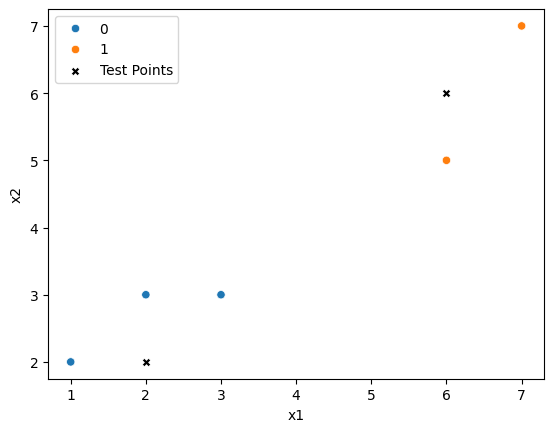

In [10]:
# Visualize
X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train

sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label"
)

X_test_df = pd.DataFrame(X_test, columns=["x1", "x2"])

sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="black",
    marker="X",
    label="Test Points"
)

In [11]:
X_train_df

,x1,x2,label
0,1,2,0
1,2,3,0
2,3,3,0
3,6,5,1
4,7,7,1


In [12]:
import numpy as np
class KNNRegressor:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))

    def _predict_one(self, x):
        # Compute distances
        distances = self._euclidean_distance(self.X_train, x)

        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get k nearest target values
        k_nearest_values = self.y_train[k_indices]

        # Return mean of neighbors
        return np.mean(k_nearest_values)

    def predict(self, X):
        X = np.array(X)
        predictions = [self._predict_one(x) for x in X]
        return np.array(predictions)


In [13]:
# Training data
X_train = np.array([[1], [2], [3], [4], [5]])
y_train = np.array([2, 4, 6, 8, 10])

# Test data
X_test = np.array([[1.5], [3.5], [6]])

# Create and train model
knn = KNNRegressor(k=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)
print("Predictions:", y_pred)


Predictions: [4. 6. 8.]
